# Value-at-Risk and Expected Shortfall Modeling

*Quant Lab · The Analytical Investor · Year 1, Month 9*

**Read the article:** [Value-at-Risk and Expected Shortfall Modeling](https://analytical-investor.blog/?p=1024)

VaR three ways and Expected Shortfall on fat-tailed returns with rare crash days, a breach backtest, and the calm-window trap that misled banks before 2008.

> Run locally with `pip install -e ".[notebooks]"` from the repo root, then open this notebook in Jupyter. All data is simulated with fixed seeds, so every number matches the article.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9, 5), "axes.grid": True, "grid.alpha": 0.3})

## Step 1
Simulate the returns, compute VaR three ways plus ES, and backtest the breaches.

In [2]:
import numpy as np

rng = np.random.default_rng(21)

# ------------------------------------------------------------------
# 1. A portfolio with hidden tail risk:
#    fat-tailed daily returns PLUS a rare jump (crash) component
# ------------------------------------------------------------------
n_days = 252 * 10                       # ten years of daily returns
mu_d, sig_d, dof = 0.08/252, 0.15/np.sqrt(252), 4

base = mu_d + rng.standard_t(dof, n_days) * sig_d / np.sqrt(dof/(dof-2))
jumps = rng.binomial(1, 0.004, n_days) * rng.normal(-0.05, 0.02, n_days)
r = base + jumps                        # ~1 crash-day per year

V = 100_000_000                         # portfolio value: 100M
alpha = 0.99                            # confidence level

# ------------------------------------------------------------------
# 2. VaR three ways
# ------------------------------------------------------------------
# (a) Parametric (variance-covariance): assumes normality
from scipy.stats import norm
var_param = -(r.mean() + r.std() * norm.ppf(1 - alpha)) * V

# (b) Historical simulation: the empirical quantile
var_hist = -np.quantile(r, 1 - alpha) * V

# (c) Monte Carlo from a fitted Student-t (fatter tails)
from scipy.stats import t as student_t
params = student_t.fit(r)
sims = student_t.rvs(*params, size=200_000, random_state=rng)
var_mc = -np.quantile(sims, 1 - alpha) * V

# ------------------------------------------------------------------
# 3. Expected Shortfall (historical)
# ------------------------------------------------------------------
tail = r[r <= np.quantile(r, 1 - alpha)]
es_hist = -tail.mean() * V

print(f"99% 1-day VaR — parametric : {var_param/1e6:6.2f} M")
print(f"99% 1-day VaR — historical : {var_hist/1e6:6.2f} M")
print(f"99% 1-day VaR — Monte Carlo: {var_mc/1e6:6.2f} M")
print(f"99% 1-day ES  — historical : {es_hist/1e6:6.2f} M")
print(f"Worst day in sample        : {-r.min()*V/1e6:6.2f} M")

# ------------------------------------------------------------------
# 4. Backtest: count VaR breaches (should be ~1% of days)
# ------------------------------------------------------------------
for name, v in [("param", var_param), ("hist", var_hist)]:
    breaches = (-r * V > v).sum()
    print(f"Breaches vs {name} VaR: {breaches} "
          f"(expected ~{n_days*(1-alpha):.0f})")

99% 1-day VaR — parametric :   2.22 M
99% 1-day VaR — historical :   2.78 M
99% 1-day VaR — Monte Carlo:   2.52 M
99% 1-day ES  — historical :   3.76 M
Worst day in sample        :   7.76 M
Breaches vs param VaR: 46 (expected ~25)
Breaches vs hist VaR: 26 (expected ~25)


## Step 2
Re-estimate parametric VaR from a calm two-year window.

In [3]:
calm = r[-504:][np.abs(r[-504:]) < 0.03]     # a jump-free window
var_calm = -(calm.mean() + calm.std() * norm.ppf(1-alpha)) * V
print(f"VaR estimated from calm window: {var_calm/1e6:.2f} M")

VaR estimated from calm window: 1.86 M


### The left tail
The parametric VaR fence sits inside the tail; ES and the worst day sit far beyond it.

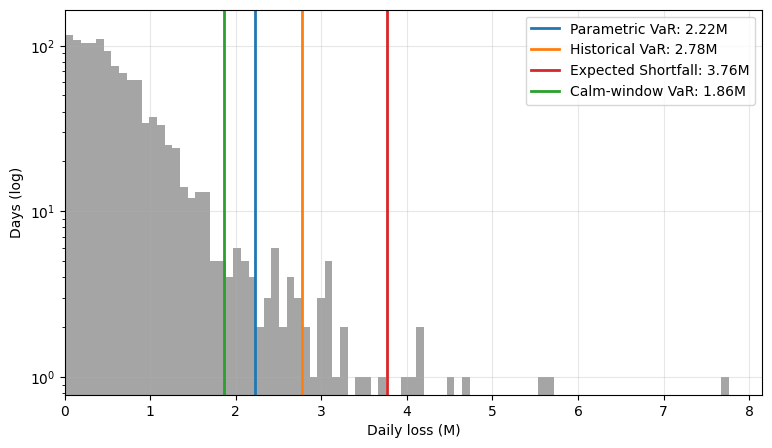

In [4]:
loss = -r * V / 1e6
plt.hist(loss, bins=200, color="tab:gray", alpha=0.7)
for val, lab, c in [(var_param/1e6, "Parametric VaR", "tab:blue"), (var_hist/1e6, "Historical VaR", "tab:orange"),
                    (es_hist/1e6, "Expected Shortfall", "tab:red"), (var_calm/1e6, "Calm-window VaR", "tab:green")]:
    plt.axvline(val, color=c, lw=2, label=f"{lab}: {val:.2f}M")
plt.xlim(0, loss.max() * 1.05); plt.yscale("log")
plt.xlabel("Daily loss (M)"); plt.ylabel("Days (log)"); plt.legend(); plt.show()

## The same thing with the toolkit
The model above lives in the `analytical_investor` package, tested and reusable.

In [5]:
from analytical_investor import risk

print(f"VaR99 {risk.var_historical(r):.4f}, ES99 {risk.expected_shortfall(r):.4f}, "
      f"breaches {risk.var_breaches(r, risk.var_parametric(r))}")

VaR99 0.0278, ES99 0.0376, breaches 46


---
The article's **Limitations** section explains what this model leaves out. [Read it here](https://analytical-investor.blog/?p=1024).